# Tutorial 3 (AY24/25 Sem 1)

In [1]:
import sympy as sym
from ma1522 import Matrix

## Question 1

Let $\mathbf{A}$ be the $4 \times 4$ matrix obtained from $\mathbf{I}$ by the following sequence of elementary row operations:

$$\mathbf{I} \xrightarrow{\frac{1}{2}R_2} \xrightarrow{R_1 - R_2} \xrightarrow{R_2 \leftrightarrow R_4} \xrightarrow{R_3 + 3R_1} \mathbf{A}$$

Write $\mathbf{A}^{-1}$ as a product of four elementary matrices.

<IPython.core.display.Math object>

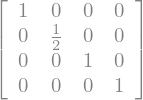

<IPython.core.display.Math object>

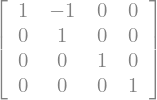

<IPython.core.display.Math object>

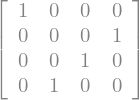

<IPython.core.display.Math object>

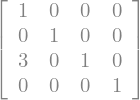

In [2]:
E_1 = Matrix.eye(4).scale_row(1, sym.Rational(1, 2))
E_2 = Matrix.eye(4).reduce_row(0, 1, 1)
E_3 = Matrix.eye(4).swap_row(1, 3)
E_4 = Matrix.eye(4).reduce_row(2, -3, 0)

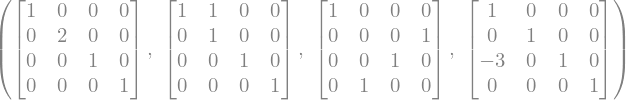

In [3]:
# The matrix A^-1 is the product of these elementary matrices
E_1**-1, E_2**-1, E_3**-1, E_4**-1

## Question 2

Find an LU factorization for the matrices $\mathbf{A}$, and solve the equation $\mathbf{A}x = b$.

### (a)

$\mathbf{A} = \begin{pmatrix} 2 & -1 & 2 \\ -6 & 0 & -2 \\ 8 & -1 & 5 \end{pmatrix}$ and $b = \begin{pmatrix} 1 \\ 0 \\ 4 \end{pmatrix}$.

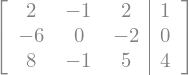

In [4]:
A = Matrix.from_str("2 -1 2; -6 0 -2; 8 -1 5")
b = Matrix.from_str("1; 0; 4")

aug_mat = A.row_join(b)
aug_mat

<IPython.core.display.Math object>

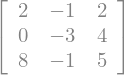

<IPython.core.display.Math object>

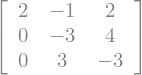

<IPython.core.display.Math object>

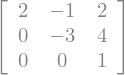

PLU(P=Matrix([
[1, 0, 0]
[0, 1, 0]
[0, 0, 1]
]), L=Matrix([
[ 1,  0, 0]
[-3,  1, 0]
[ 4, -1, 1]
]), U=Matrix([
[2, -1, 2]
[0, -3, 4]
[0,  0, 1]
]))

In [5]:
plu = A.ref(verbosity=2)
plu # The LU factorization of A is given by the matrices L and U
# You may ignore P as it is the identity matrix, which suggest that it is LU factorisable.

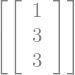

In [6]:
y = plu.L.solve(b)
y

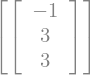

In [8]:
x = plu.U.solve(y[0])
x

### (b)

$\mathbf{A} = \begin{pmatrix} 2 & -4 & 4 & -2 \\ 6 & -9 & 7 & -3 \\ -1 & -4 & 8 & 0 \end{pmatrix}$ and $b = \begin{pmatrix} 0 \\ 0 \\ 5 \end{pmatrix}$.

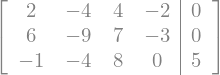

In [9]:
A = Matrix.from_str("2 -4 4 -2; 6 -9 7 -3; -1 -4 8 0")
b = Matrix.from_str("0; 0; 5")

aug_mat = A.row_join(b)
aug_mat

<IPython.core.display.Math object>

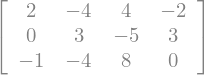

<IPython.core.display.Math object>

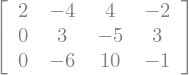

<IPython.core.display.Math object>

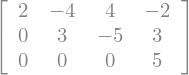

PLU(P=Matrix([
[1, 0, 0]
[0, 1, 0]
[0, 0, 1]
]), L=Matrix([
[   1,  0, 0]
[   3,  1, 0]
[-1/2, -2, 1]
]), U=Matrix([
[2, -4,  4, -2]
[0,  3, -5,  3]
[0,  0,  0,  5]
]))

In [10]:
plu = A.ref(verbosity=2)
plu

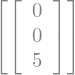

In [11]:
y = plu.L.solve(b)
y

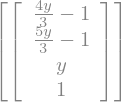

In [12]:
x = plu.U.solve(y[0])
x

## Question 3

Let $\mathbf{A} = \begin{pmatrix} 2 & -6 & 6 \\ -4 & 5 & -7 \\ 3 & 5 & -1 \\ -6 & 4 & -8 \\ 8 & -3 & 9 \end{pmatrix}$.

### (a)

Find an LU factorization of $\mathbf{A}$.

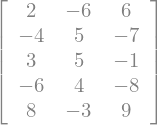

In [13]:
A = Matrix.from_str("2 -6 6; -4 5 -7; 3 5 -1; -6 4 -8; 8 -3 9")
A

<IPython.core.display.Math object>

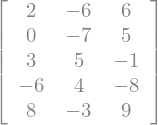

<IPython.core.display.Math object>

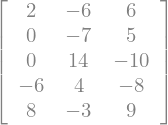

<IPython.core.display.Math object>

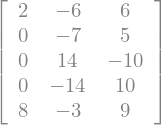

<IPython.core.display.Math object>

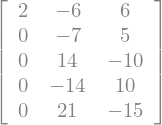

<IPython.core.display.Math object>

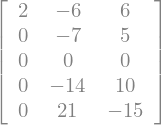

<IPython.core.display.Math object>

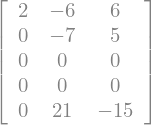

<IPython.core.display.Math object>

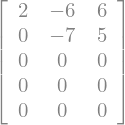

PLU(P=Matrix([
[1, 0, 0, 0, 0]
[0, 1, 0, 0, 0]
[0, 0, 1, 0, 0]
[0, 0, 0, 1, 0]
[0, 0, 0, 0, 1]
]), L=Matrix([
[  1,  0, 0, 0, 0]
[ -2,  1, 0, 0, 0]
[3/2, -2, 1, 0, 0]
[ -3,  2, 0, 1, 0]
[  4, -3, 0, 0, 1]
]), U=Matrix([
[2, -6, 6]
[0, -7, 5]
[0,  0, 0]
[0,  0, 0]
[0,  0, 0]
]))

In [14]:
plu = A.ref(verbosity=2)
plu

## Question 4

Let $\mathbf{A} = \begin{pmatrix} -x & 1 & 0 \\ 0 & -x & 1 \\ 2 & -5 & 4-x \end{pmatrix}$. Compute the determinant of $\mathbf{A}$ and find all the values of $x$ such that $\mathbf{A}$ is singular.

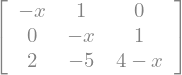

In [15]:
A = Matrix.from_str("-x 1 0; 0 -x 1; 2 -5 4-x")
A

In [16]:
A.det().factor()

## Question 5

Show that $$\begin{vmatrix} a + px & b + qx & c + rx \\ p + ux & q + vx & r + wx \\ u + ax & v + bx & w + cx \end{vmatrix} = (1 + x^3) \begin{vmatrix} a & b & c \\ p & q & r \\ u & v & w \end{vmatrix}$$

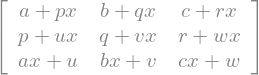

In [17]:
a, b, c, p, q, r, u, v, w, x = sym.symbols("a b c p q r u v w x")

lhs = Matrix([[a + p*x, b + q*x, c + r*x],
              [p + u*x, q + v*x, r + w*x],
              [u + a*x, v + b*x, w + c*x]])

lhs

In [18]:
lhs.det()

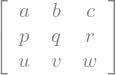

In [19]:
rhs = Matrix.from_str("a b c; p q r; u v w")
rhs

In [20]:
rhs.det()

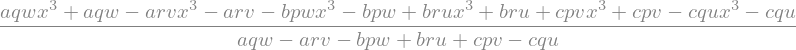

In [21]:
sym.simplify(lhs.det() / rhs.det())

<IPython.core.display.Math object>

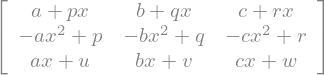

<IPython.core.display.Math object>

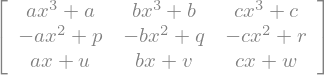

<IPython.core.display.Math object>

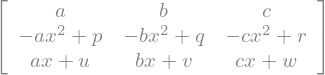

<IPython.core.display.Math object>

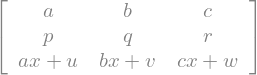

<IPython.core.display.Math object>

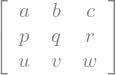

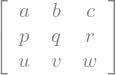

In [22]:
# Alternative way: less brute force

(lhs.copy()
 .reduce_row(1, x, 2)
 .reduce_row(0, x, 1)
 .scale_row(0, 1/(1 + x**3))
 .reduce_row(1, -x**2, 0)
 .reduce_row(2, x, 0)
 )

In [23]:
# Therefore, det has only been scaled by a factor of 1 + x**3

## Question 7

Use Cramer's rule to solve 
$$\begin{cases} 
x &+& 5y &+& 3z &=& 1 \\ 
&& 2y &-& 2z &=& 2 \\
&& y &+& 3z &=& 0 
\end{cases}$$

Modified matrix for column 1:


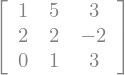

<IPython.core.display.Math object>

Modified matrix for column 2:


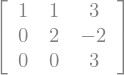

<IPython.core.display.Math object>

Modified matrix for column 3:


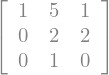

<IPython.core.display.Math object>

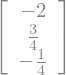

In [24]:
mat = Matrix.from_str("1 5 3; 0 2 -2; 0 1 3")
rhs = Matrix.from_str("1; 2; 0")

mat.cramer_solve(rhs, verbosity=2)

## Question 8

Compute the adjoint of $\mathbf{A} = \begin{pmatrix} 1 & -1 & 2 \\ 0 & 2 & 1 \\ 3 & 0 & 6 \end{pmatrix}$, and use it to compute $\mathbf{A}^{-1}$.

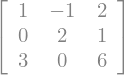

In [25]:
A = Matrix.from_str("1 -1 2; 0 2 1; 3 0 6")

A

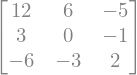

In [26]:
# Note: Please use `adj` method instead of `adjoint` or `adjugate` 
# even if they are aliased correctly based on MA1522 definitions as
# they are not the same as the SymPy's `adjoint` or `adjugate` methods.

A.adj()

C:\Users\yeesh\AppData\Local\Temp\ipykernel_32724\2803142297.py:1: DeprecationWarning: The classical adjoint of the matrix is computed rather than the conjugate transpose.
            Please use self.adj() instead to remove ambiguity.
  A.adjoint()


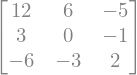

In [27]:
A.adjoint()

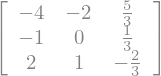

In [28]:
A_inv = A.adj() / A.det()
A_inv